In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install --no-deps stable-baselines3==2.1.0
!pip install --no-deps gym==0.25.2
!pip install --no-deps shimmy==1.1.0


  Attempting uninstall: shimmy
    Found existing installation: Shimmy 1.3.0
    Uninstalling Shimmy-1.3.0:
      Successfully uninstalled Shimmy-1.3.0


In [3]:
# !pip install stable-baselines3[extra]==2.1.0 gym==0.25.2 shimmy==1.1.0


In [4]:
!pip uninstall -y tensorboard tensorboard-data-server


Found existing installation: tensorboard 2.18.0
Uninstalling tensorboard-2.18.0:
  Successfully uninstalled tensorboard-2.18.0
Found existing installation: tensorboard-data-server 0.7.2
Uninstalling tensorboard-data-server-0.7.2:
  Successfully uninstalled tensorboard-data-server-0.7.2


In [5]:
import gym
from gym import spaces
import numpy as np
import pandas as pd
import yfinance as yf

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

import matplotlib.pyplot as plt


In [6]:
import gym
from gym import spaces
import numpy as np
import pandas as pd
import yfinance as yf


class PortfolioEnv(gym.Env):
    """
    Model-free RL environment for long-only portfolio allocation
    with daily data (Δt = 1 day), now with **market regime awareness**.

    Compatible with:
    - gym <= 0.25 (classic API: reset() -> obs, step() -> obs, reward, done, info)
    - stable-baselines3 == 2.1.0
    """

    metadata = {"render.modes": ["human"]}

    def __init__(
        self,
        tickers=("AAPL", "MSFT", "GOOGL"),
        start="2018-01-01",
        end="2023-01-01",
        initial_capital=1_000_000,
        transaction_cost=0.001,
        window_size=30,
        vol_window=20,   # rolling window for volatility (in days)
    ):
        super().__init__()

        self.tickers = list(tickers)
        self.n_assets = len(self.tickers)
        self.start = start
        self.end = end
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost
        self.window_size = window_size
        self.vol_window = vol_window

        # Load price data and compute returns + regimes
        self._load_data()

        # --- Action space: continuous weights (will be softmax-normalized) ---
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(self.n_assets,), dtype=np.float32
        )

        # --- Observation space: window of returns + previous weights + regime one-hot ---
        # window: window_size * n_assets
        # prev_weights: n_assets
        # regime: 3 (Low, High, Crash)
        obs_dim = self.window_size * self.n_assets + self.n_assets + 3
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )

        self.current_step = None
        self.portfolio_value = None
        self.prev_weights = None

    # ==========================================================
    # Data loading + regime computation
    # ==========================================================
    def _load_data(self):
        # Force auto_adjust=False so 'Adj Close' exists
        data = yf.download(
            self.tickers,
            start=self.start,
            end=self.end,
            progress=False,
            auto_adjust=False
        )
        prices = data["Adj Close"].dropna()
        self.dates = prices.index
        self.prices = prices.values  # shape (T, n_assets)

        # Daily asset returns
        self.returns = self.prices[1:] / self.prices[:-1] - 1.0  # (T-1, n_assets)

        # Compute market regimes based on volatility of average return
        self._compute_regimes()

    def _compute_regimes(self):
        """
        Compute market regimes:
            0 = Low Volatility
            1 = High Volatility
            2 = Crash (very high volatility)
        based on rolling std of average asset returns.
        """
        # Market return as average of asset returns (shape: T-1,)
        mkt_ret = self.returns.mean(axis=1)

        n = len(mkt_ret)
        vol = np.zeros(n, dtype=np.float64)

        # Rolling volatility over vol_window
        for t in range(n):
            start_idx = max(0, t - self.vol_window + 1)
            window = mkt_ret[start_idx:t + 1]
            vol[t] = np.std(window)

        # Use global mean volatility as baseline
        mean_vol = np.mean(vol)

        # Initialize all as Low Volatility (0)
        regimes = np.zeros(n, dtype=np.int64)

        # High Vol: between 1 * mean_vol and 2 * mean_vol
        regimes[(vol >= mean_vol) & (vol < 2 * mean_vol)] = 1

        # Crash: very high vol
        regimes[vol >= 2 * mean_vol] = 2

        self.regimes = regimes  # shape (T-1,)

        # Optional: print distribution for sanity check
        unique, counts = np.unique(regimes, return_counts=True)
        print("Regime distribution (0=Low,1=High,2=Crash):")
        for r, c in zip(unique, counts):
            print(f"  Regime {r}: {c} steps")

    # ==========================================================
    # Gym API: reset() and step()
    # ==========================================================
    def reset(self):
        """
        Reset environment and return initial observation (Gym <=0.25).
        """
        self.current_step = self.window_size
        self.portfolio_value = self.initial_capital
        self.prev_weights = np.ones(self.n_assets) / self.n_assets

        obs = self._get_observation()
        return obs

    def step(self, action):
        # Convert raw action to valid portfolio weights via softmax
        weights = self._softmax(action)

        # Asset returns for this step
        asset_returns = self.returns[self.current_step - 1]

        # Portfolio return BEFORE transaction costs
        port_ret_before = np.dot(weights, asset_returns)

        # Turnover and transaction cost
        turnover = np.sum(np.abs(weights - self.prev_weights))
        cost = self.transaction_cost * turnover

        # Net portfolio return AFTER cost
        port_ret_after = port_ret_before - cost

        # Update portfolio value
        prev_value = self.portfolio_value
        self.portfolio_value *= (1.0 + port_ret_after)

        # Reward: log-return
        reward = float(np.log(self.portfolio_value / prev_value))

        # Update state
        self.prev_weights = weights
        self.current_step += 1

        done = False

        # Ruin condition: portfolio dropped below 50% of initial
        if self.portfolio_value < 0.5 * self.initial_capital:
            done = True

        # End-of-data condition
        if self.current_step >= len(self.returns):
            done = True

        obs = self._get_observation()
        info = {
            "portfolio_value": float(self.portfolio_value),
            "weights": weights,
            "turnover": float(turnover),
            "step": int(self.current_step),
        }

        return obs, reward, done, info

    # ==========================================================
    # Observation construction
    # ==========================================================
    def _get_observation(self):
        # Past window of returns
        start = self.current_step - self.window_size
        end = self.current_step
        window_returns = self.returns[start:end]           # (window_size, n_assets)
        window_flat = window_returns.flatten()             # (window_size * n_assets,)

        # Regime at current step (aligned with self.returns index)
        regime_idx = self.regimes[self.current_step - 1]   # 0,1,2
        regime_one_hot = np.zeros(3, dtype=np.float32)
        regime_one_hot[regime_idx] = 1.0

        # Full observation: [returns window, prev_weights, regime_one_hot]
        obs = np.concatenate([window_flat, self.prev_weights, regime_one_hot], axis=0)
        return obs.astype(np.float32)

    # ==========================================================
    # Utils
    # ==========================================================
    @staticmethod
    def _softmax(x):
        x = np.asarray(x, dtype=np.float64)
        x = x - np.max(x)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x)

    def render(self, mode="human"):
        print(
            f"Step: {self.current_step}, "
            f"Portfolio Value: {self.portfolio_value:.2f}"
        )


In [7]:
env = PortfolioEnv()
obs = env.reset()
print("Observation shape:", obs.shape)
env.render()


Regime distribution (0=Low,1=High,2=Crash):
  Regime 0: 704 steps
  Regime 1: 515 steps
  Regime 2: 39 steps
Observation shape: (96,)
Step: 30, Portfolio Value: 1000000.00


In [8]:
def make_env():
    return PortfolioEnv(
        tickers=("AAPL", "MSFT", "GOOGL"),
        start="2018-01-01",
        end="2023-01-01",
        initial_capital=1_000_000,
        transaction_cost=0.001,
        window_size=30,
    )

vec_env = DummyVecEnv([make_env])

model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    learning_rate=3e-4,
    batch_size=64,
    n_steps=2048,
    gamma=0.99,
)

total_timesteps = 100_000  # increase for better performance
model.learn(total_timesteps=total_timesteps)

model.save("ppo_portfolio_model")


Regime distribution (0=Low,1=High,2=Crash):
  Regime 0: 704 steps
  Regime 1: 515 steps
  Regime 2: 39 steps
Using cuda device


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 734  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 581         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004509907 |
|    clip_fraction        | 0.0228      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.27       |
|    explained_variance   | -0.539      |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0352     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0046     |
|    std                  | 1.01        |
|    value_loss           | 0.0032      |
----------------------------------

Regime distribution (0=Low,1=High,2=Crash):
  Regime 0: 704 steps
  Regime 1: 515 steps
  Regime 2: 39 steps
Final portfolio value: 6,076,491.54


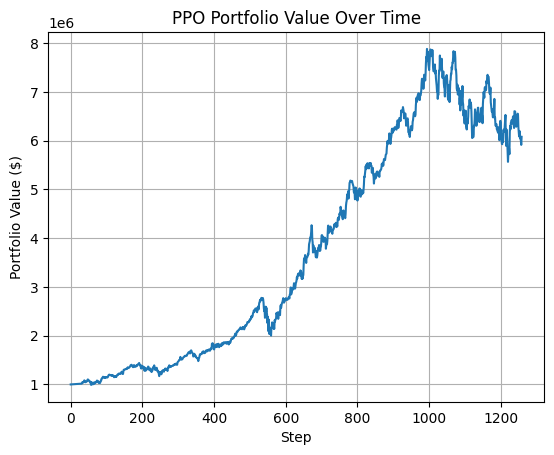

In [9]:
eval_env = make_env()
obs = eval_env.reset()   # <-- only one value now
done = False

values = [eval_env.initial_capital]
steps = [0]

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = eval_env.step(action)  # old gym API: obs, reward, done, info
    values.append(info["portfolio_value"])
    steps.append(info["step"])

print(f"Final portfolio value: {values[-1]:,.2f}")

import matplotlib.pyplot as plt

plt.plot(steps, values)
plt.xlabel("Step")
plt.ylabel("Portfolio Value ($)")
plt.title("PPO Portfolio Value Over Time")
plt.grid(True)
plt.show()


Regime distribution (0=Low,1=High,2=Crash):
  Regime 0: 704 steps
  Regime 1: 515 steps
  Regime 2: 39 steps
Regimes shape: (1258,)
First 10 regimes: [0 0 0 0 0 0 0 0 0 0]
Legend: 0 = Low Vol, 1 = High Vol, 2 = Crash


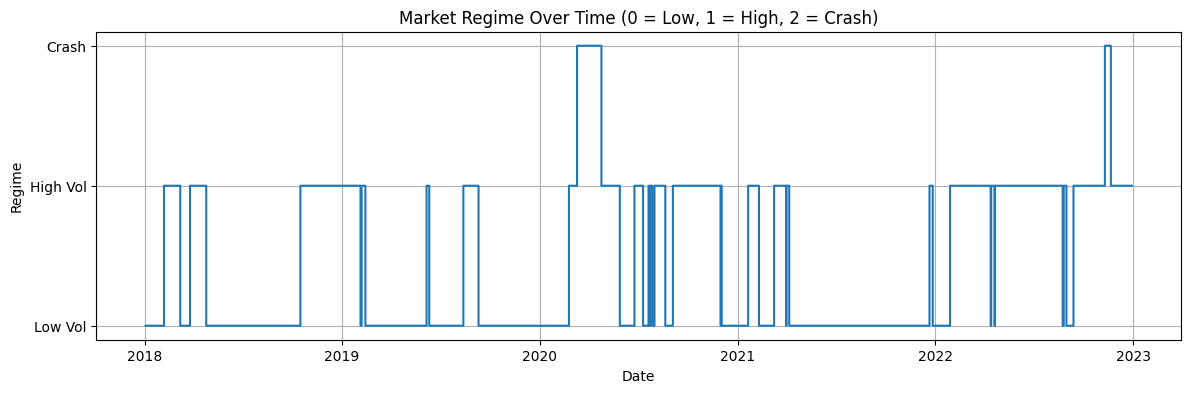

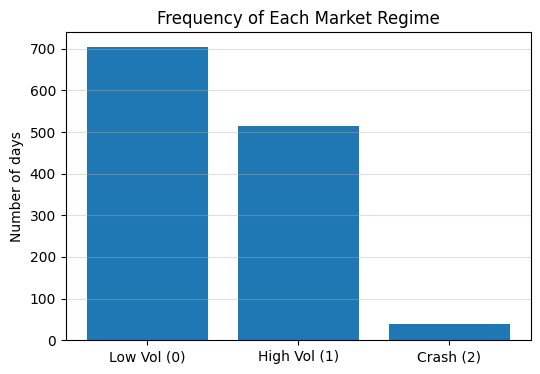

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Create a fresh environment (regimes are computed in __init__)
regime_env = PortfolioEnv(
    tickers=("AAPL", "MSFT", "GOOGL"),
    start="2018-01-01",
    end="2023-01-01",
    initial_capital=1_000_000,
    transaction_cost=0.001,
    window_size=30,
    vol_window=20,
)

# Dates for regimes: aligned with returns, so skip first price row
dates = regime_env.dates[1:]          # shape: (T-1,)
regimes = regime_env.regimes          # shape: (T-1,)

print("Regimes shape:", regimes.shape)
print("First 10 regimes:", regimes[:10])
print("Legend: 0 = Low Vol, 1 = High Vol, 2 = Crash")

# ------------------ Time series plot ------------------
plt.figure(figsize=(14, 4))
plt.step(dates, regimes, where="post")
plt.yticks([0, 1, 2], ["Low Vol", "High Vol", "Crash"])
plt.xlabel("Date")
plt.ylabel("Regime")
plt.title("Market Regime Over Time (0 = Low, 1 = High, 2 = Crash)")
plt.grid(True)
plt.show()

# ------------------ Regime counts bar chart ------------------
unique, counts = np.unique(regimes, return_counts=True)
labels = ["Low Vol (0)", "High Vol (1)", "Crash (2)"]
count_map = {int(u): c for u, c in zip(unique, counts)}

plt.figure(figsize=(6,4))
plt.bar(
    [0, 1, 2],
    [count_map.get(0, 0), count_map.get(1, 0), count_map.get(2, 0)],
    tick_label=labels,
)
plt.ylabel("Number of days")
plt.title("Frequency of Each Market Regime")
plt.grid(axis="y", alpha=0.4)
plt.show()


Regime distribution (0=Low,1=High,2=Crash):
  Regime 0: 704 steps
  Regime 1: 515 steps
  Regime 2: 39 steps
Final portfolio value: 6,076,491.54
Regime legend: 0 = Low Vol, 1 = High Vol, 2 = Crash


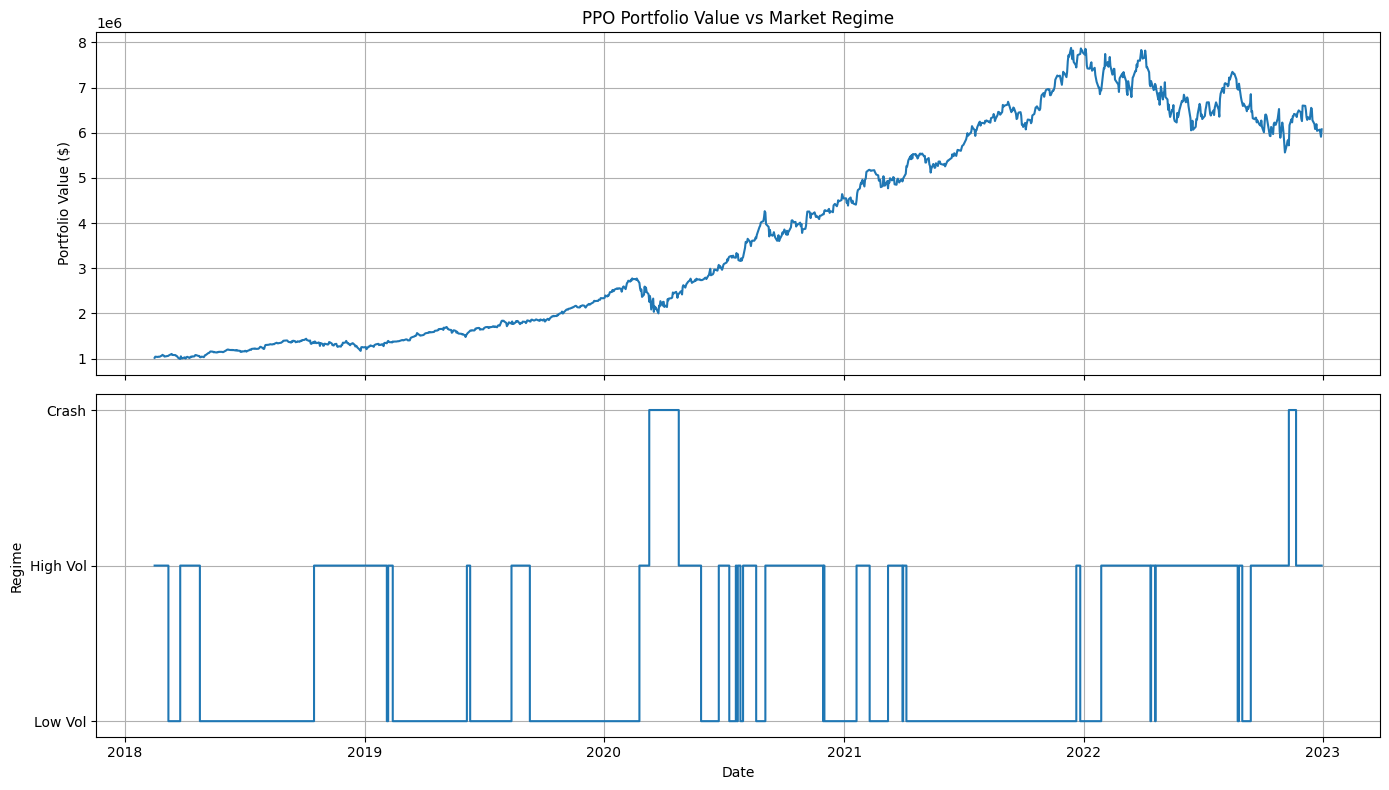

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Recreate evaluation environment (same config as training)
eval_env = PortfolioEnv(
    tickers=("AAPL", "MSFT", "GOOGL"),
    start="2018-01-01",
    end="2023-01-01",
    initial_capital=1_000_000,
    transaction_cost=0.001,
    window_size=30,
    vol_window=20,
)

obs = eval_env.reset()
done = False

portfolio_values = [eval_env.initial_capital]
steps = [0]
regime_path = []
date_path = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = eval_env.step(action)

    # current step info
    portfolio_values.append(info["portfolio_value"])
    steps.append(info["step"])

    # regime at this step (aligned with returns index)
    regime_idx = eval_env.regimes[eval_env.current_step - 1]  # 0,1,2
    regime_path.append(int(regime_idx))

    # date at this step
    # eval_env.dates has shape (T,), and returns is (T-1,)
    # current_step corresponds to index current_step in dates
    if eval_env.current_step < len(eval_env.dates):
        date_path.append(eval_env.dates[eval_env.current_step])
    else:
        date_path.append(eval_env.dates[-1])

final_value = portfolio_values[-1]
print(f"Final portfolio value: {final_value:,.2f}")
print("Regime legend: 0 = Low Vol, 1 = High Vol, 2 = Crash")

# ------------------ Plot: Portfolio vs Regime ------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: portfolio value
ax1.plot(date_path, portfolio_values[1:len(date_path)+1])
ax1.set_ylabel("Portfolio Value ($)")
ax1.set_title("PPO Portfolio Value vs Market Regime")
ax1.grid(True)

# Bottom: regime path
ax2.step(date_path, regime_path, where="post")
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(["Low Vol", "High Vol", "Crash"])
ax2.set_xlabel("Date")
ax2.set_ylabel("Regime")
ax2.grid(True)

plt.tight_layout()
plt.show()


In [12]:
import numpy as np

def sharpe_ratio(returns, risk_free=0.0):
    """
    Annualized Sharpe Ratio using daily returns.
    """
    if len(returns) < 2:
        return 0.0
    
    mean_ret = np.mean(returns) - risk_free
    std_ret = np.std(returns)

    if std_ret == 0:
        return 0.0

    # Annualize (252 trading days)
    return (mean_ret / std_ret) * np.sqrt(252)


# --------------------------------------------------------
# Compute regime-specific returns
# --------------------------------------------------------
regime_returns = {0: [], 1: [], 2: []}

for i in range(len(portfolio_values) - 1):
    ret = np.log(portfolio_values[i+1] / portfolio_values[i])   # log-return
    r = regime_path[i]                                          # regime at this step
    regime_returns[r].append(ret)

# --------------------------------------------------------
# Calculate Sharpe for each regime
# --------------------------------------------------------
sharpe_low  = sharpe_ratio(regime_returns[0])
sharpe_high = sharpe_ratio(regime_returns[1])
sharpe_crash = sharpe_ratio(regime_returns[2])

print("===== Sharpe Ratio by Market Regime =====")
print(f"Low Volatility   (Regime 0): {sharpe_low:.4f}")
print(f"High Volatility  (Regime 1): {sharpe_high:.4f}")
print(f"Crash Regime     (Regime 2): {sharpe_crash:.4f}")

# Optional: count days per regime
print("\nData points per regime:")
print(f"Low Volatility:   {len(regime_returns[0])}")
print(f"High Volatility:  {len(regime_returns[1])}")
print(f"Crash:            {len(regime_returns[2])}")


===== Sharpe Ratio by Market Regime =====
Low Volatility   (Regime 0): 2.5765
High Volatility  (Regime 1): 0.4182
Crash Regime     (Regime 2): 0.8024

Data points per regime:
Low Volatility:   681
High Volatility:  508
Crash:            39


In [13]:
import numpy as np

# compute daily returns from portfolio values
values = np.array(values)
returns = values[1:] / values[:-1] - 1

# compute sharpe ratio
sharpe = (np.mean(returns) / np.std(returns)) * np.sqrt(252)

print("===== Sharpe Ratio (Original PPO Model) =====")
print(f"Sharpe Ratio: {sharpe:.4f}")


===== Sharpe Ratio (Original PPO Model) =====
Sharpe Ratio: 1.3764
